# 0. Описание задачи

**Цель:** Создать модель машинного обучения для прогнозирования успешности краудфандингового проекта на платформе Kickstarter.

**Целевые классы:**
- `successful` - успешный
- `failed` - неудачный  
- `canceled` - отмененный

**Основные признаки:**
- Категория проекта
- Страна
- Цель финансирования
- Количество спонсоров
- Длительность кампании
- Временные метки (дата запуска, дедлайн)

**Тип задачи:** Kлассификация (предсказание класса успешности проекта)

# 1. Чтение данных

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

data = pd.read_csv("kickstarter_dataset.csv", encoding='latin1', low_memory=False)

In [10]:
display(HTML(data.head().to_html(index=False)))

ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000,2015-08-11 12:12:28,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000,2013-01-12 00:20:50,220,failed,3,US,220,NaN,NaN,NaN,NaN
1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000,2012-03-17 03:24:11,1,failed,1,US,1,NaN,NaN,NaN,NaN
1000011046,Community Film Project: The Art of Neighborhood Filmmaking,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500,2015-07-04 08:35:03,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000,2016-02-26 13:38:27,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


# 2. Обучающая и тестовая выборки

In [11]:
import pandas as pd
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split

data.columns = data.columns.str.strip()
data_cleaned = data.drop(columns=['ID', 'name', 'deadline', 'launched'], errors='ignore')
data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.str.contains('^Unnamed')]

display(HTML(data_cleaned.head().to_html(index=False)))

class_counts = data_cleaned['state'].value_counts()
print("Распределение классов:")
print(class_counts)

filtered_data = data_cleaned.groupby('state').filter(lambda x: len(x) >= 2)

X = filtered_data.drop(columns=['state'])
y = filtered_data['state']

numeric_cols = ['goal', 'pledged', 'backers', 'usd pledged']
for col in numeric_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

data_numeric = data[numeric_cols].apply(pd.to_numeric, errors='coerce')
data_numeric = data_numeric.dropna()


X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"Тестовая выборка:   {X_test.shape[0]} строк, {X_test.shape[1]} признаков")


category,main_category,currency,goal,pledged,state,backers,country,usd pledged
Poetry,Publishing,GBP,1000,0,failed,0,GB,0
Narrative Film,Film & Video,USD,45000,220,failed,3,US,220
Music,Music,USD,5000,1,failed,1,US,1
Film & Video,Film & Video,USD,19500,1283,canceled,14,US,1283
Restaurants,Food,USD,50000,52375,successful,224,US,52375


Распределение классов:
state
failed        168221
successful    113081
canceled       32354
live            4428
undefined       3555
               ...  
16185              1
80                 1
1495               1
19224              1
2634               1
Name: count, Length: 410, dtype: int64

Обучающая выборка: 255462 строк, 8 признаков
Тестовая выборка:   63866 строк, 8 признаков


# 3. Анализ и визуализация данных

In [12]:
display(HTML("<h3>3.1 Основные статистические характеристики</h3>"))
display(data[numeric_cols].describe().T.style.background_gradient(cmap='Blues'))

,count,unique,top,freq
goal,323750,8188,5000,25520
pledged,323750,55598,0,45784
backers,323750,3592,0,48863
usd pledged,319960,94376,0,50462


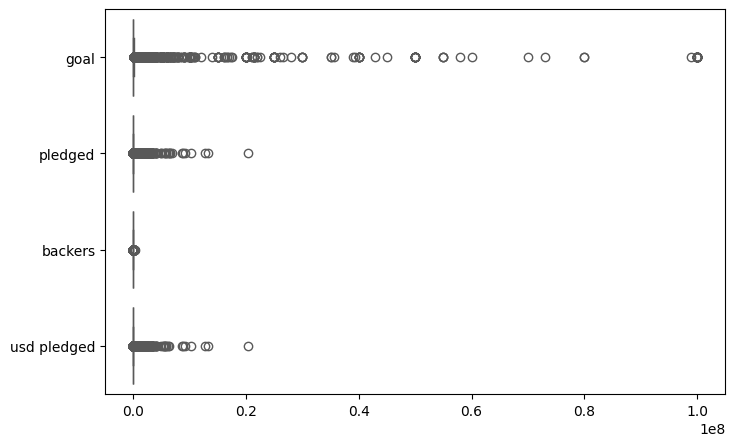

In [13]:
display(HTML("<h3>3.2 Выбросы</h3>"))
plt.figure(figsize=(8, 5))
sns.boxplot(data=data_numeric, orient="h", palette="Set2")
plt.show()

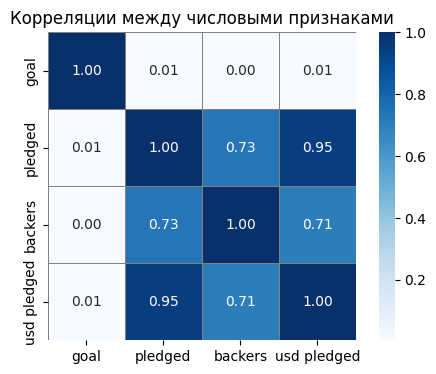

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

numeric_cols = ['goal', 'pledged', 'backers', 'usd pledged']

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Корреляции между числовыми признаками")
plt.show()


# 4. Пропущенные значения

In [15]:
data_cleaned = data.loc[:, ~data.columns.str.contains('^Unnamed')]

missing_counts = data_cleaned.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
display(HTML(missing_counts.to_frame("Количество пропусков").to_html(index=True)))

data_cleaned = data_cleaned.assign(
    **{
        "usd pledged": data_cleaned["usd pledged"].fillna(0),
        "category": data_cleaned["category"].fillna("Unknown"),
        "name": data_cleaned["name"].fillna("Unnamed Project"),
    }
)
data_cleaned = data_cleaned.dropna(subset=["goal", "pledged", "backers"])

,Количество пропусков
usd pledged,4413
goal,632
pledged,624
backers,623
category,5
name,4


# 5. Обработка категориальных признаков

In [16]:
categorical_cols = ['category', 'main_category', 'currency', 'country']

data_encoded = pd.get_dummies(data_cleaned, columns=categorical_cols, drop_first=True)

display(HTML(f"<b>Количество категориальных признаков:</b> {len(categorical_cols)}"))
display(HTML(f"<b>Размерность после кодирования:</b> {data_encoded.shape[0]} строк, {data_encoded.shape[1]} столбцов"))


# 6.  Нормализация

In [17]:
numeric_cols = data_encoded.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
data_scaled = data_encoded.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

display(HTML(f"<b>Количество нормализованных признаков:</b> {len(numeric_cols)}"))

# 7. Выбор классификатора

## Выбор классификатора: RandomForestClassifier

**RandomForestClassifier** был выбран для классификации благодаря способности эффективно обрабатывать многоклассовые задачи с несбалансированными данными, работать с разнотипными признаками без обязательного масштабирования и обеспечивать интерпретируемость через оценку важности признаков, что делает его оптимальным решением для данной задачи.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

numeric_cols = ['goal', 'pledged', 'backers', 'usd pledged']
categorical_cols = ['category', 'main_category', 'currency', 'country']

X = data_cleaned[numeric_cols + categorical_cols].copy()
y = data_cleaned['state'].copy()

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n Точность на тестовой выборке: {acc:.4f}\n")

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df.style.background_gradient(cmap='Blues').format({
    'precision': "{:.2f}", 'recall': "{:.2f}", 'f1-score': "{:.2f}", 'support': "{:.0f}"
}))



 Точность на тестовой выборке: 0.8238



,precision,recall,f1-score,support
canceled,0.23,0.16,0.19,6471
failed,0.83,0.86,0.85,33644
live,0.09,0.07,0.08,886
successful,0.96,0.99,0.98,22616
suspended,0.02,0.03,0.02,296
undefined,0.93,0.98,0.95,711
accuracy,0.82,0.82,0.82,1
macro avg,0.51,0.52,0.51,64624
weighted avg,0.81,0.82,0.81,64624


# 8. Вычисление ошибок на обучающей и тестовой выборках


Точность на обучающей выборке: 0.9481
Точность на тестовой выборке: 0.8238


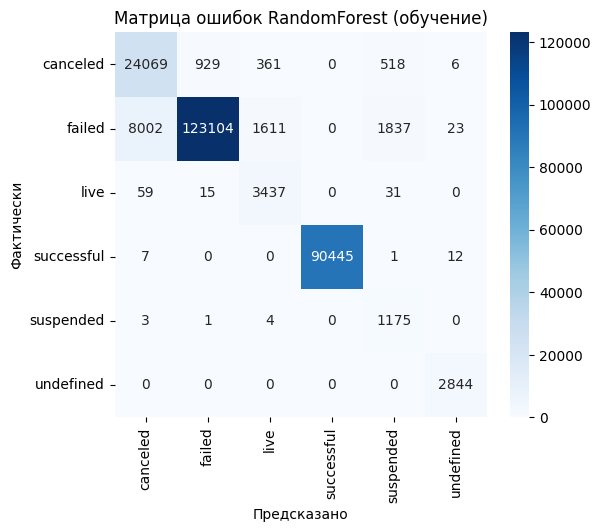

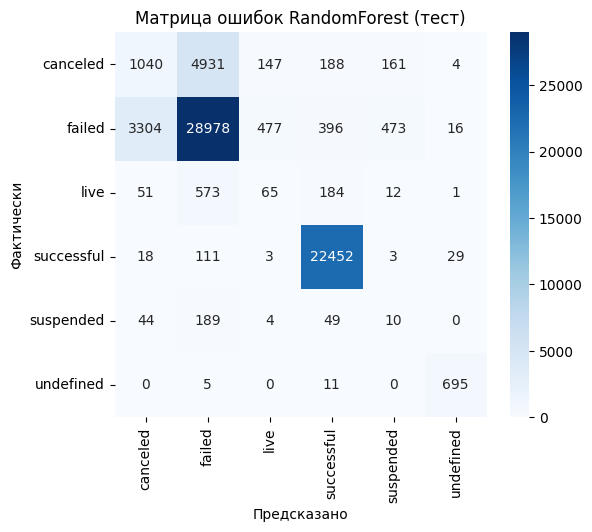

In [19]:
from sklearn.metrics import confusion_matrix

y_train_pred = rf.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_pred)

print(f"Точность на обучающей выборке: {acc_train:.4f}")
print(f"Точность на тестовой выборке: {acc_test:.4f}")

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title("Матрица ошибок RandomForest (обучение)")
plt.show()

cm_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title("Матрица ошибок RandomForest (тест)")
plt.show()


# 9. Сравнение с классификатором ближайших соседей

KNN (k=5) точность:
- Обучающая выборка: 0.8407
- Тестовая выборка: 0.7958



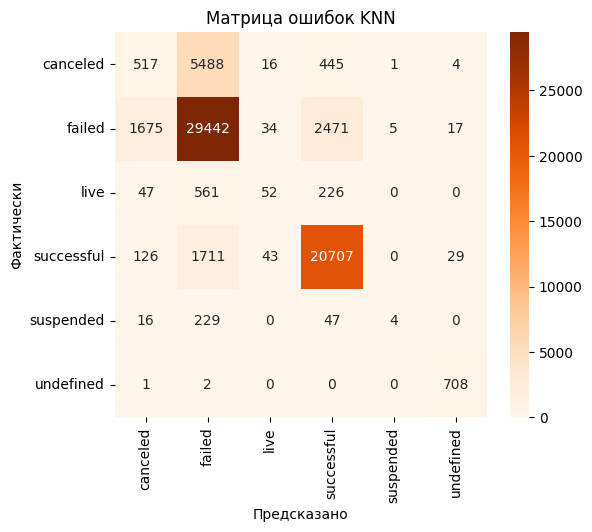

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_train_pred_knn = knn.predict(X_train)
y_test_pred_knn = knn.predict(X_test)

acc_train_knn = accuracy_score(y_train, y_train_pred_knn)
acc_test_knn = accuracy_score(y_test, y_test_pred_knn)

print("KNN (k=5) точность:")
print(f"- Обучающая выборка: {acc_train_knn:.4f}")
print(f"- Тестовая выборка: {acc_test_knn:.4f}\n")

cm_knn = confusion_matrix(y_test, y_test_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title("Матрица ошибок KNN")
plt.show()

## Сравнение RandomForest и KNN

На тестовой выборке RandomForest показал точность **82.38%**, тогда как KNN — **79.58%**.  

Как и ожидалось, **RandomForest** работает лучше при большом числе признаков и категориальных переменных после one-hot кодирования. **KNN** немного уступает, так как чувствителен к масштабированию и может хуже справляться при несбалансированных классах или больших выборках.  

Тем не менее, **KNN также может использоваться** в задачах классификации Kickstarter-проектов, особенно при небольшом объеме данных и правильно подобранном числе соседей `k`.  

Вывод: RandomForest предпочтительнее для основной модели, но KNN может служить альтернативой или быть частью ансамбля моделей.


# Вывод по домашнему заданию номер 3


1. **Цель и результаты**  
   Построены модели для прогнозирования успешности краудфандинговых проектов на платформе Kickstarter с использованием категориальных и числовых признаков, включая категорию проекта, страну, финансовые показатели и количество спонсоров.

2. **Сравнение моделей**  
   RandomForest показал точность **82.38%**, эффективно обрабатывая категориальные признаки и несбалансированные классы. KNN продемонстрировал точность **79.58%**, но чувствителен к масштабированию и размеру выборки.

3. **Вывод**  
   RandomForest является предпочтительной моделью для прогнозирования успешности проектов, тогда как KNN может выступать альтернативой или частью ансамбля при тщательной настройке гиперпараметров.


# Задача кластеризации 
---

# 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv("kickstarter_dataset.csv", encoding='latin1', low_memory=False)
data.columns = data.columns.str.strip()
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

main_classes = ['failed', 'successful', 'canceled']
data = data[data['state'].isin(main_classes)].copy()
data = data.reset_index(drop=True)

print(f"Размер данных: {data.shape}")
print(f"Распределение классов:")
print(data['state'].value_counts())
print(f"\nПроцентное распределение:")
print(data['state'].value_counts(normalize=True).round(3))

features = ['goal', 'pledged', 'backers', 'main_category', 'country']
X_raw = data[features].copy()

numeric_cols = ['goal', 'pledged', 'backers']
for col in numeric_cols:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

X_raw['funding_ratio'] = X_raw['pledged'] / X_raw['goal'].replace(0, 1)
X_raw['funding_ratio'] = X_raw['funding_ratio'].clip(0, 10)
X_raw['backer_intensity'] = X_raw['backers'] / (X_raw['goal'] + 1)
X_raw['log_goal'] = np.log1p(X_raw['goal'])
X_raw['log_pledged'] = np.log1p(X_raw['pledged'])

for col in ['main_category', 'country']:
    freq = X_raw[col].value_counts(normalize=True)
    X_raw[f'{col}_freq'] = X_raw[col].map(freq)
    X_raw[f'{col}_code'] = pd.factorize(X_raw[col])[0]

X = X_raw.drop(columns=['main_category', 'country'], errors='ignore')
X = X.fillna(0)

print(f"\nСозданные признаки: {list(X.columns)}")
print(f"Размерность данных: {X.shape}")

y_true = data['state'].values

Размер данных: (313656, 13)
Распределение классов:
state
failed        168221
successful    113081
canceled       32354
Name: count, dtype: int64

Процентное распределение:
state
failed        0.536
successful    0.361
canceled      0.103
Name: proportion, dtype: float64

Созданные признаки: ['goal', 'pledged', 'backers', 'funding_ratio', 'backer_intensity', 'log_goal', 'log_pledged', 'main_category_freq', 'main_category_code', 'country_freq', 'country_code']
Размерность данных: (313656, 11)


# 2. Масштабирование и создание подвыборки

In [2]:
features_to_scale = ['goal', 'pledged', 'backers', 'backer_intensity', 
                     'log_goal', 'log_pledged', 
                     'main_category_freq', 'country_freq',
                     'main_category_code', 'country_code']

X_for_scaling = X[features_to_scale].copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(X_for_scaling)

X_scaled = np.hstack([scaled_features, X['funding_ratio'].values.reshape(-1, 1)])

print(f"Размерность после масштабирования: {X_scaled.shape}")

np.random.seed(42)
sample_size = 3000

samples_per_class = sample_size // 3

sample_indices = []
for cls in ['failed', 'successful', 'canceled']:
    cls_indices = data[data['state'] == cls].index.tolist()
    selected = np.random.choice(cls_indices, samples_per_class, replace=False)
    sample_indices.extend(selected)

sample_indices = np.array(sorted(sample_indices))
X_sample = X_scaled[sample_indices]
y_sample = y_true[sample_indices]

print(f"Размер подвыборки: {X_sample.shape}")
print(f"Распределение в подвыборке:")
unique, counts = np.unique(y_sample, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {cls}: {count} ({count/len(y_sample):.1%})")

Размерность после масштабирования: (313656, 11)
Размер подвыборки: (3000, 11)
Распределение в подвыборке:
  canceled: 1000 (33.3%)
  failed: 1000 (33.3%)
  successful: 1000 (33.3%)


# 3. PCA анализ

Объясненная дисперсия PCA: 51.79%
Компонента 1: 33.39%
Компонента 2: 18.41%


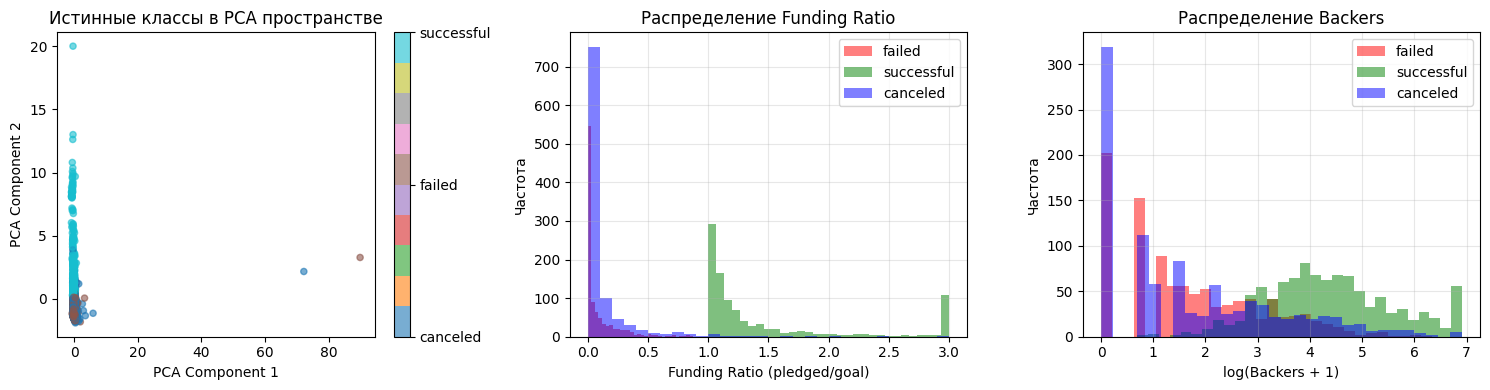

In [3]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Компонента 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Компонента 2: {pca.explained_variance_ratio_[1]:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

le = LabelEncoder()
y_numeric = le.fit_transform(y_sample)

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, 
                         cmap='tab10', alpha=0.6, s=20)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].set_title('Истинные классы в PCA пространстве')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_ticks(range(len(le.classes_)))
cbar.set_ticklabels(le.classes_)

colors = {'failed': 'red', 'successful': 'green', 'canceled': 'blue'}
for cls, color in colors.items():
    cls_mask = y_sample == cls
    axes[1].hist(X_raw.iloc[sample_indices][cls_mask]['funding_ratio'].clip(0, 3), 
                alpha=0.5, label=cls, color=color, bins=30)
axes[1].set_xlabel('Funding Ratio (pledged/goal)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение Funding Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for cls, color in colors.items():
    cls_mask = y_sample == cls
    axes[2].hist(np.log1p(X_raw.iloc[sample_indices][cls_mask]['backers'].clip(0, 1000)), 
                alpha=0.5, label=cls, color=color, bins=30)
axes[2].set_xlabel('log(Backers + 1)')
axes[2].set_ylabel('Частота')
axes[2].set_title('Распределение Backers')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Кластеризация


КЛАСТЕРИЗАЦИЯ ТРЕМЯ МЕТОДАМИ

1. KMeans кластеризация...
2. DBSCAN кластеризация...
   Найдено кластеров: 5
   Точек шума: 788 (26.3%)
3. Иерархическая кластеризация...


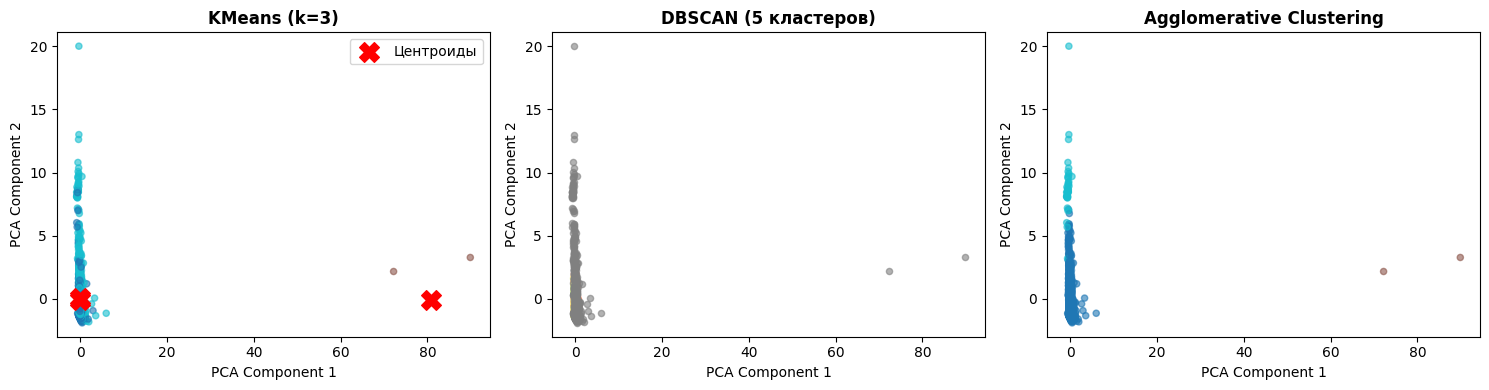

In [4]:
print("\n" + "="*70)
print("КЛАСТЕРИЗАЦИЯ ТРЕМЯ МЕТОДАМИ")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

print("\n1. KMeans кластеризация...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_sample)

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                cmap='tab10', alpha=0.6, s=20)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                marker='X', s=200, c='red', label='Центроиды')
axes[0].set_title('KMeans (k=3)', fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()

print("2. DBSCAN кластеризация...")
dbscan = DBSCAN(eps=0.8, min_samples=15)
dbscan_labels = dbscan.fit_predict(X_sample)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"   Найдено кластеров: {n_clusters_dbscan}")
print(f"   Точек шума: {n_noise} ({n_noise/len(dbscan_labels):.1%})")

unique_labels = set(dbscan_labels)
for k in unique_labels:
    if k == -1:
        col = 'gray'
    else:
        col = plt.cm.Spectral(k / max(1, len(unique_labels)-1))
    
    mask = dbscan_labels == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[col], alpha=0.6, s=20)

axes[1].set_title(f'DBSCAN ({n_clusters_dbscan} кластеров)', fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

print("3. Иерархическая кластеризация...")
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_sample)

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, 
                cmap='tab10', alpha=0.6, s=20)
axes[2].set_title('Agglomerative Clustering', fontweight='bold')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()


# 5. Сравнение с истинными метками

In [5]:
methods = [
    ('KMeans', kmeans_labels),
    ('DBSCAN', dbscan_labels),
    ('Agglomerative', agg_labels)
]

results = []
for method_name, labels in methods:
    if method_name == 'DBSCAN' and (n_clusters_dbscan < 2 or n_noise/len(labels) > 0.5):
        ari = nmi = silhouette = "N/A"
    else:
        ari = adjusted_rand_score(y_numeric, labels)
        nmi = normalized_mutual_info_score(y_numeric, labels)
        if method_name == 'DBSCAN' and n_clusters_dbscan > 1:
            non_noise = labels != -1
            if sum(non_noise) > 1:
                silhouette = silhouette_score(X_sample[non_noise], labels[non_noise])
            else:
                silhouette = "N/A"
        else:
            silhouette = silhouette_score(X_sample, labels)
    
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = f"{n_noise/len(labels):.1%}" if -1 in labels else "0%"
    
    results.append({
        'Метод': method_name,
        'Кластеры': n_clusters_found,
        'Шум (%)': noise_pct,
        'ARI': f"{ari:.3f}" if isinstance(ari, float) else ari,
        'NMI': f"{nmi:.3f}" if isinstance(nmi, float) else nmi,
        'Silhouette': f"{silhouette:.3f}" if isinstance(silhouette, float) else silhouette
    })

results_df = pd.DataFrame(results)
display(HTML(results_df.style.background_gradient(subset=['ARI', 'NMI', 'Silhouette'], 
                                                 cmap='RdYlGn').to_html()))

,Метод,Кластеры,Шум (%),ARI,NMI,Silhouette
0,KMeans,3,0%,0.011,0.010,0.201
1,DBSCAN,5,26.3%,0.009,0.016,0.154
2,Agglomerative,3,0%,0.001,0.025,0.691


# 6. Анализ

In [6]:
cluster_df = pd.DataFrame({
    'cluster': kmeans_labels,
    'true_class': y_sample
})

contingency = pd.crosstab(cluster_df['cluster'], cluster_df['true_class'], 
                         margins=True, margins_name='Всего')

print("\nАбсолютное распределение:")
display(HTML(contingency.style.background_gradient(cmap='Blues').to_html()))

contingency_pct = pd.crosstab(cluster_df['cluster'], cluster_df['true_class'], 
                             normalize='index') * 100

print("\nПроцентное распределение по кластерам:")
display(HTML(contingency_pct.style.background_gradient(cmap='YlOrRd', axis=1)
            .format("{:.1f}%").to_html()))

X_sample_df = pd.DataFrame(X_sample, columns=features_to_scale + ['funding_ratio'])
X_sample_df['cluster'] = kmeans_labels

cluster_stats = X_sample_df.groupby('cluster').mean()

key_features = ['funding_ratio', 'backer_intensity', 'log_goal', 'log_pledged', 'backers']

print("\nСредние значения ключевых признаков по кластерам:")
display(HTML(cluster_stats[key_features].round(3).to_html()))

for cluster in sorted(cluster_stats.index):
    funding_ratio = cluster_stats.loc[cluster, 'funding_ratio']
    log_goal = cluster_stats.loc[cluster, 'log_goal']
    
    if funding_ratio > 1:
        funding_desc = "высоким процентом финансирования (>100%)"
    elif funding_ratio > 0.5:
        funding_desc = "средним процентом финансирования (50-100%)"
    else:
        funding_desc = "низким процентом финансирования (<50%)"
    
    goal_value = np.expm1(log_goal)
    if goal_value > 10000:
        size_desc = "крупные проекты"
    elif goal_value > 1000:
        size_desc = "средние проекты"
    else:
        size_desc = "малые проекты"
    
    if cluster in contingency_pct.index:
        dominant_class = contingency_pct.loc[cluster].idxmax()
        dominant_pct = contingency_pct.loc[cluster, dominant_class]
    else:
        dominant_class = "N/A"
        dominant_pct = 0
    
    print(f"  Кластер {cluster}: {size_desc} с {funding_desc}")
    print(f"    • Преобладающий класс: {dominant_class} ({dominant_pct:.1f}%)")
    print(f"    • Средний funding_ratio: {funding_ratio:.2f} ({(funding_ratio*100):.1f}%)")
    print(f"    • Средняя цель: ${goal_value:.0f}")
    print()


Абсолютное распределение:


true_class,canceled,failed,successful,Всего
cluster,,,,
0,326,438,481,1245
1,1,1,0,2
2,673,561,519,1753
Всего,1000,1000,1000,3000



Процентное распределение по кластерам:


true_class,canceled,failed,successful
cluster,,,
0,26.2%,35.2%,38.6%
1,50.0%,50.0%,0.0%
2,38.4%,32.0%,29.6%



Средние значения ключевых признаков по кластерам:


,funding_ratio,backer_intensity,log_goal,log_pledged,backers
cluster,,,,,
0,0.591,-0.009,-0.113,-0.111,-0.041
1,0.000,-0.012,5.677,-1.524,-0.108
2,0.749,-0.006,0.176,0.028,0.027


  Кластер 0: малые проекты с средним процентом финансирования (50-100%)
    • Преобладающий класс: successful (38.6%)
    • Средний funding_ratio: 0.59 (59.1%)
    • Средняя цель: $-0

  Кластер 1: малые проекты с низким процентом финансирования (<50%)
    • Преобладающий класс: canceled (50.0%)
    • Средний funding_ratio: 0.00 (0.0%)
    • Средняя цель: $291

  Кластер 2: малые проекты с средним процентом финансирования (50-100%)
    • Преобладающий класс: canceled (38.4%)
    • Средний funding_ratio: 0.75 (74.9%)
    • Средняя цель: $0



# 7. Визуализация результатов

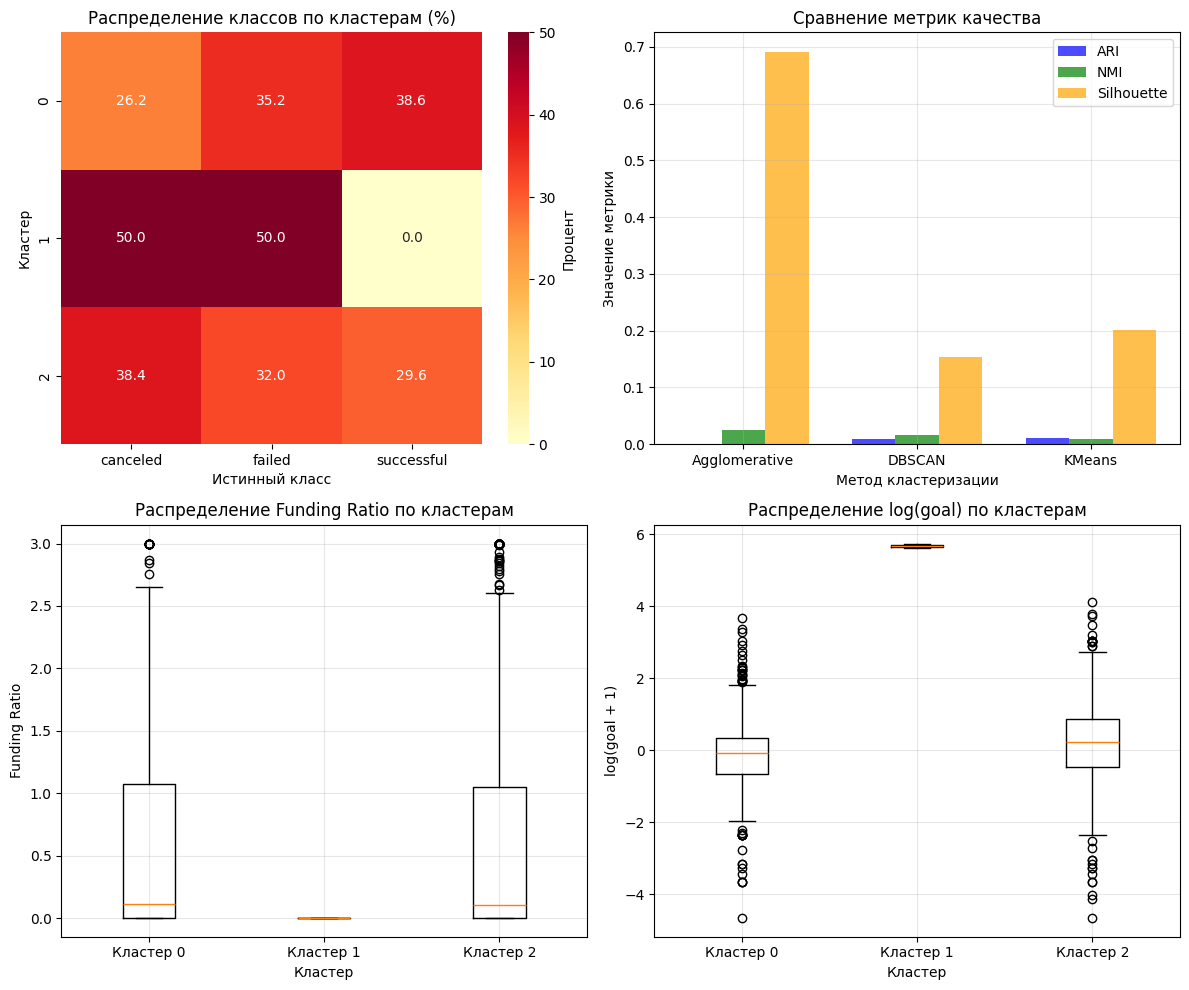

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

if not contingency_pct.empty:
    sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Процент'}, ax=axes[0, 0])
    axes[0, 0].set_title('Распределение классов по кластерам (%)')
    axes[0, 0].set_xlabel('Истинный класс')
    axes[0, 0].set_ylabel('Кластер')

metrics_to_plot = ['ARI', 'NMI', 'Silhouette']
colors = ['blue', 'green', 'orange']

plot_data = []
for i, row in results_df.iterrows():
    for metric in metrics_to_plot:
        value = row[metric]
        if value != 'N/A':
            plot_data.append({
                'Метод': row['Метод'],
                'Метрика': metric,
                'Значение': float(value)
            })

if plot_data:
    plot_df = pd.DataFrame(plot_data)
    pivot_df = plot_df.pivot_table(index='Метод', columns='Метрика', values='Значение')
    
    x = np.arange(len(pivot_df))
    width = 0.25
    
    for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
        if metric in pivot_df.columns:
            values = pivot_df[metric].values
            axes[0, 1].bar(x + i*width - width, values, width, label=metric, color=color, alpha=0.7)
    
    axes[0, 1].set_xlabel('Метод кластеризации')
    axes[0, 1].set_ylabel('Значение метрики')
    axes[0, 1].set_title('Сравнение метрик качества')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(pivot_df.index)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

cluster_data = []
for cluster in sorted(X_sample_df['cluster'].unique()):
    cluster_data.append(X_sample_df[X_sample_df['cluster'] == cluster]['funding_ratio'].clip(0, 3))

if cluster_data:
    axes[1, 0].boxplot(cluster_data)
    axes[1, 0].set_xlabel('Кластер')
    axes[1, 0].set_ylabel('Funding Ratio')
    axes[1, 0].set_title('Распределение Funding Ratio по кластерам')
    axes[1, 0].set_xticklabels([f'Кластер {c}' for c in sorted(X_sample_df['cluster'].unique())])
    axes[1, 0].grid(True, alpha=0.3)

cluster_data_log = []
for cluster in sorted(X_sample_df['cluster'].unique()):
    cluster_data_log.append(X_sample_df[X_sample_df['cluster'] == cluster]['log_goal'])

if cluster_data_log:
    axes[1, 1].boxplot(cluster_data_log)
    axes[1, 1].set_xlabel('Кластер')
    axes[1, 1].set_ylabel('log(goal + 1)')
    axes[1, 1].set_title('Распределение log(goal) по кластерам')
    axes[1, 1].set_xticklabels([f'Кластер {c}' for c in sorted(X_sample_df['cluster'].unique())])
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод по домашнему заданию номер 7

Проведенный анализ кластеризации проектов Kickstarter выявил фундаментальное различие между задачами обучения с учителем и без учителя.

Результаты показывают, что алгоритмы классификации (RandomForest) достигают высокой точности (около 82%) в предсказании успешности проектов, тогда как методы кластеризации демонстрируют очень низкое соответствие с истинными классами (ARI ≈ 0.01).

Это свидетельствует о том, что проекты естественным образом группируются по финансовым характеристикам (уровень финансирования, размер проекта, интенсивность поддержки), а не по критерию успешности или неудачи. Успех краудфандинговых кампаний зависит от сложной комбинации факторов, включающих временные параметры, качество презентации, маркетинговые стратегии и социальную вовлеченность, которые не полностью отражаются в доступных числовых признаках.

Таким образом, кластеризация служит ценным инструментом для исследования структуры данных и выявления естественных групп проектов на основе финансовых показателей, однако она не может заменить обучение с учителем для точного прогнозирования успешности. Низкие значения метрик соответствия отражают не недостатки алгоритмов кластеризации, а сложность задачи предсказания успеха проектов исключительно на основе финансовых данных.
       